In [25]:
import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

print('TensorFlow version:', tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.19.0


In [4]:
DATA_DIR = '/kaggle/input/gtsrb-german-traffic-sign'
TARGET_SIZE = (64, 64)
BATCH_SIZE = 64
EPOCHS = 30
NUM_CLASSES = None

MODEL_SAVE_PATH = 'traffic_sign_model.h5'
CLASSES_JSON = 'classes.json'

In [5]:
train_dir = os.path.join(DATA_DIR, 'Train')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    horizontal_flip=False,
    validation_split=0.15
)

valid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = valid_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

class_indices = train_generator.class_indices
NUM_CLASSES = len(class_indices)

classes_inv = {v: k for k, v in class_indices.items()}
with open(CLASSES_JSON, 'w') as f:
    json.dump(classes_inv, f)

print('Number of classes:', NUM_CLASSES)
print('Number of categories:', NUM_CLASSES)
print('Number of training images:', train_generator.samples)
print('Number of verification images:', val_generator.samples)
print('Category distribution:', class_indices)

Found 33337 images belonging to 43 classes.
Found 5872 images belonging to 43 classes.
Number of classes: 43
Number of categories: 43
Number of training images: 33337
Number of verification images: 5872
Category distribution: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


Samples of training data:


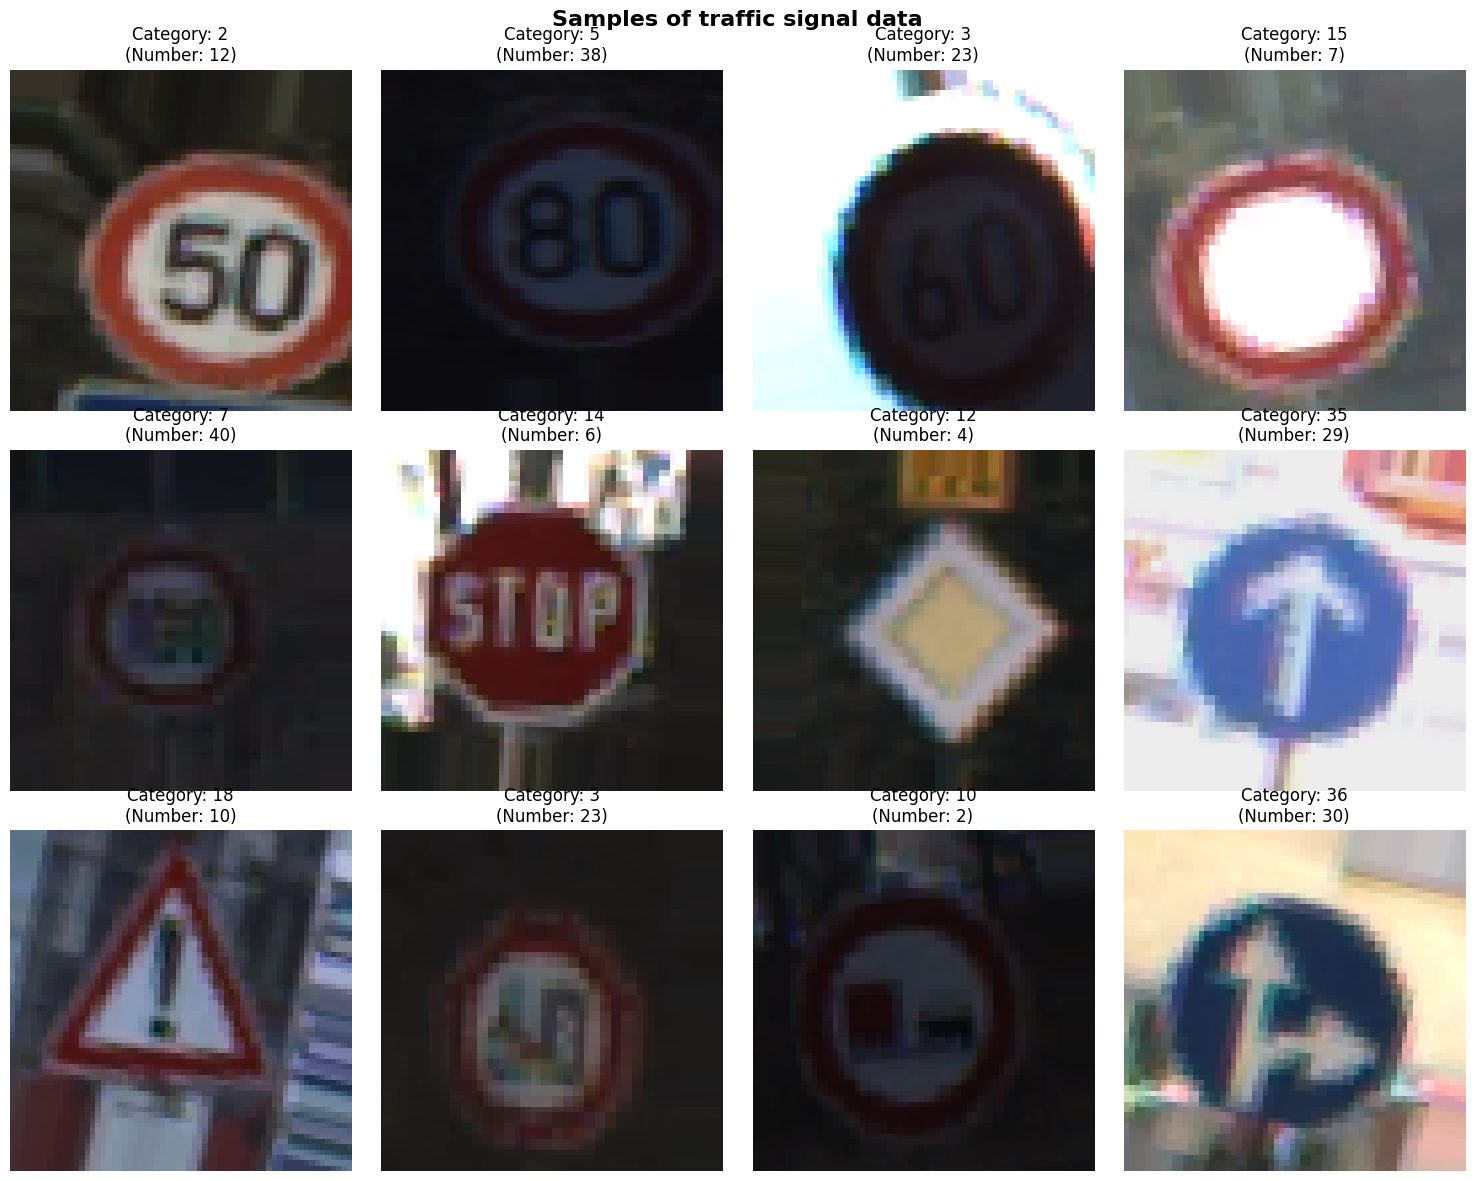

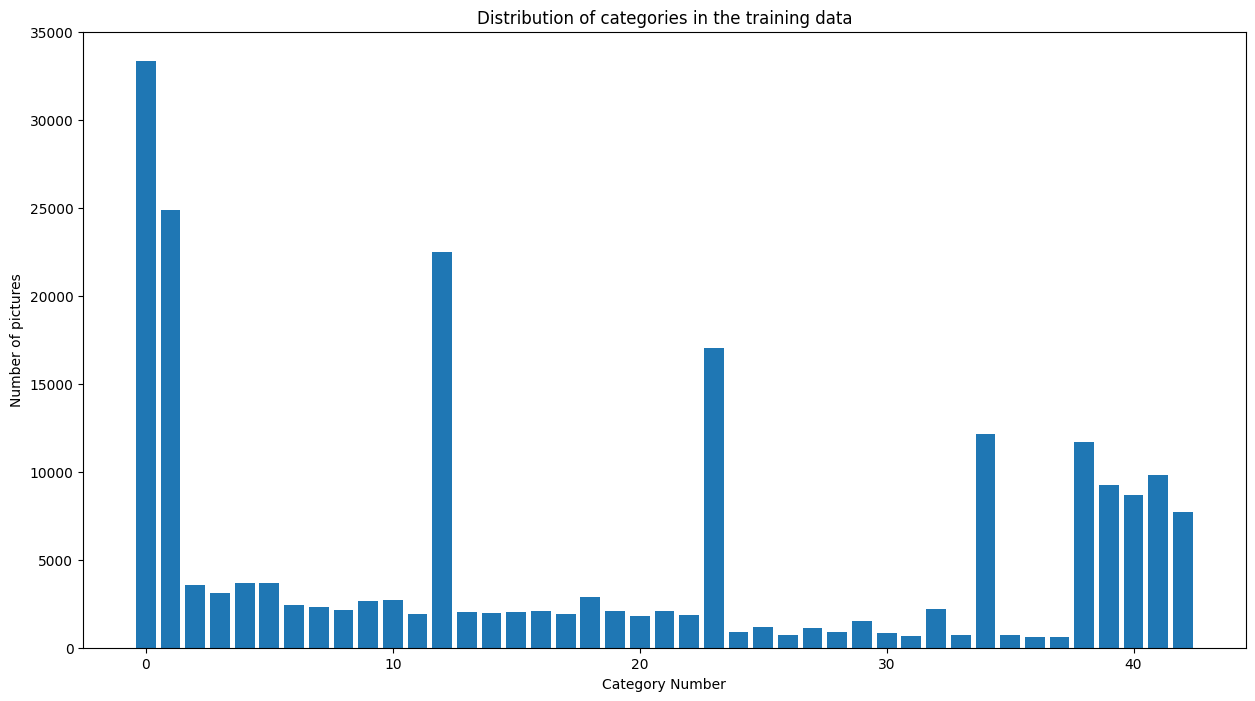

In [6]:
def show_sample_images(generator, num_samples=12):
    """
    عرض عينات من الصور والفئات المقابلة لها
    """
    images, labels = next(generator)

    class_labels = np.argmax(labels, axis=1)

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    fig.suptitle('Samples of traffic signal data', fontsize=16, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            ax.imshow(images[i])

            class_idx = class_labels[i]
            class_name = classes_inv.get(class_idx, f"Class {class_idx}")

            ax.set_title(f'Category: {class_name}\n(Number: {class_idx})')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

print("Samples of training data:")
show_sample_images(train_generator)

class_counts = {}
for class_name, class_idx in class_indices.items():
    count = sum(1 for path in train_generator.filepaths if class_name in path)
    class_counts[class_name] = count

plt.figure(figsize=(15, 8))
plt.bar(range(len(class_counts)), list(class_counts.values()))
plt.title('Distribution of categories in the training data')
plt.xlabel('Category Number')
plt.ylabel('Number of pictures')
plt.show()

In [7]:
def build_custom_cnn(input_shape=(64, 64, 3), n_classes=NUM_CLASSES):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ])

    return model

model = build_custom_cnn()
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model summary:")
model.summary()

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,628,171 (17.66 MB)

 Trainable params: 4,626,187 (17.65 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr, model_checkpoint]

print("بدء التدريب...")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=5,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks,
    verbose=1
)

print("تم الانتهاء من التدريب!")

بدء التدريب...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2439 - loss: 3.0471
Epoch 1: val_accuracy improved from -inf to 0.60525, saving model to traffic_sign_model.h5


521/521 ━━━━━━━━━━━━━━━━━━━━ 1199s 2s/step - accuracy: 0.2442 - loss: 3.0453 - val_accuracy: 0.6052 - val_loss: 1.2551 - learning_rate: 0.0010
Epoch 2/5
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7525 - loss: 0.7528
Epoch 2: val_accuracy improved from 0.60525 to 0.88624, saving model to traffic_sign_model.h5


521/521 ━━━━━━━━━━━━━━━━━━━━ 1233s 2s/step - accuracy: 0.7526 - loss: 0.7524 - val_accuracy: 0.8862 - val_loss: 0.3475 - learning_rate: 0.0010
Epoch 3/5
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9245 - loss: 0.2529
Epoch 3: val_accuracy improved from 0.88624 to 0.96407, saving model to traffic_sign_model.h5


521/521 ━━━━━━━━━━━━━━━━━━━━ 1163s 2s/step - accuracy: 0.9245 - loss: 0.2528 - val_accuracy: 0.9641 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 4/5
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9633 - loss: 0.1226
Epoch 4: val_accuracy did not improve from 0.96407
521/521 ━━━━━━━━━━━━━━━━━━━━ 1218s 2s/step - accuracy: 0.9633 - loss: 0.1226 - val_accuracy: 0.9601 - val_loss: 0.1619 - learning_rate: 0.0010
Epoch 5/5
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9695 - loss: 0.0991
Epoch 5: val_accuracy did not improve from 0.96407
521/521 ━━━━━━━━━━━━━━━━━━━━ 1195s 2s/step - accuracy: 0.9695 - loss: 0.0991 - val_accuracy: 0.9384 - val_loss: 0.2355 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
تم الانتهاء من التدريب!


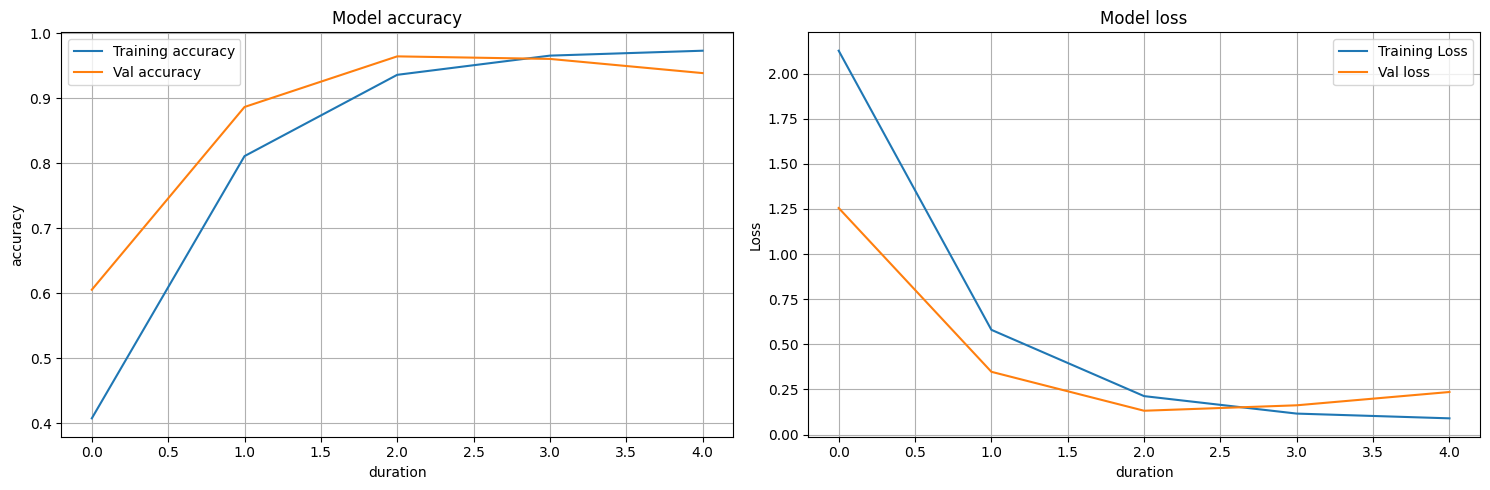

Evaluating the model on validation data:
Val loss: 0.1317
Val accuracy: 0.9641


In [9]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['accuracy'], label='Training accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
    axes[0].set_title('Model accuracy')
    axes[0].set_xlabel('duration')
    axes[0].set_ylabel('accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Val loss')
    axes[1].set_title('Model loss')
    axes[1].set_xlabel('duration')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

print("Evaluating the model on validation data:")
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f'Val loss: {val_loss:.4f}')
print(f'Val accuracy: {val_accuracy:.4f}')

92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 517ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.07      0.07      0.07       333
           2       0.05      0.05      0.05       301
           3       0.05      0.06      0.06       198
           4       0.04      0.04      0.04       315
           5       0.06      0.06      0.06       324
           6       0.02      0.02      0.02       117
           7       0.02      0.01      0.01        94
           8       0.02      0.02      0.02        63
           9       0.02      0.02      0.02       166
          10       0.03      0.03      0.03       180
          11       0.04      0.03      0.04        31
          12       0.05      0.05      0.05       337
          13       0.00      0.00      0.00        54
          14       0.02      0.02      0.02        49
          15       0.02      0.02      0.02        58
          16    

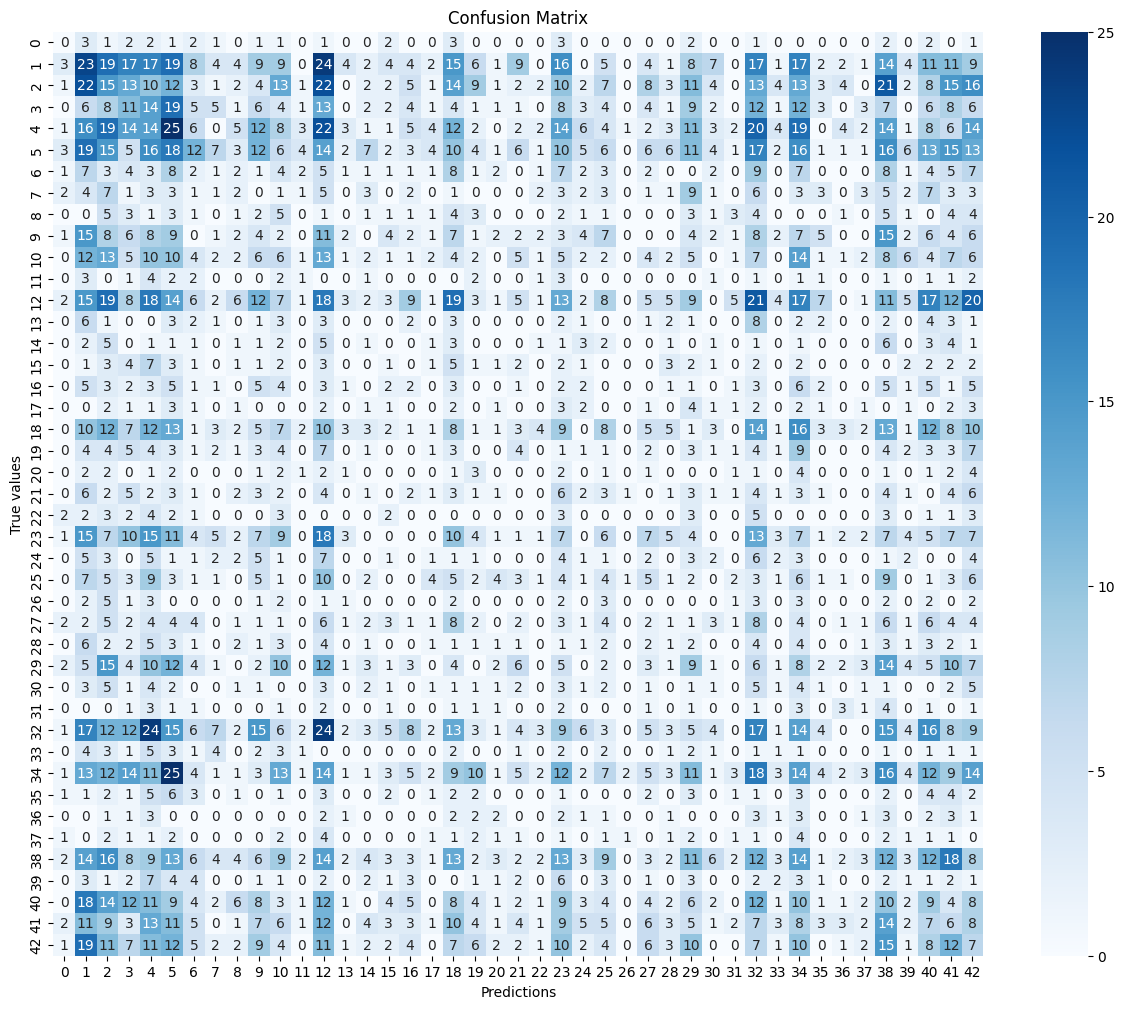

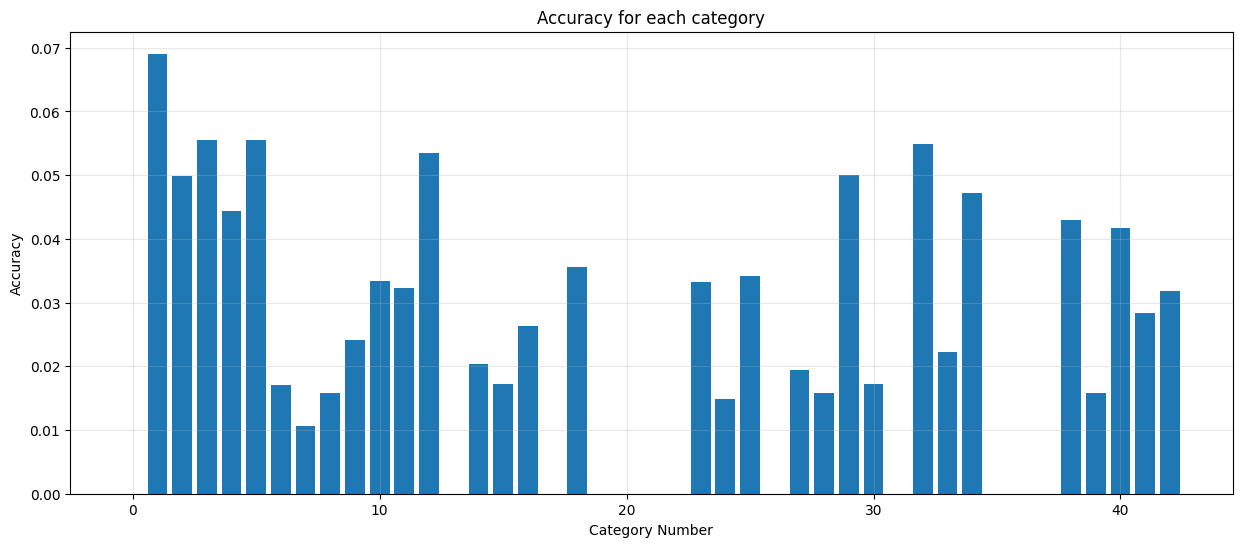

In [10]:
val_generator.reset()

predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

print("Classification Report:")
print(classification_report(true_classes, predicted_classes))

plt.figure(figsize=(15, 12))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.title('Confusion Matrix')
plt.xlabel('Predictions')
plt.ylabel('True values')
plt.show()

class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(15, 6))
plt.bar(range(NUM_CLASSES), class_accuracy)
plt.title('Accuracy for each category')
plt.xlabel('Category Number')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

Testing the model on images from the validation set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


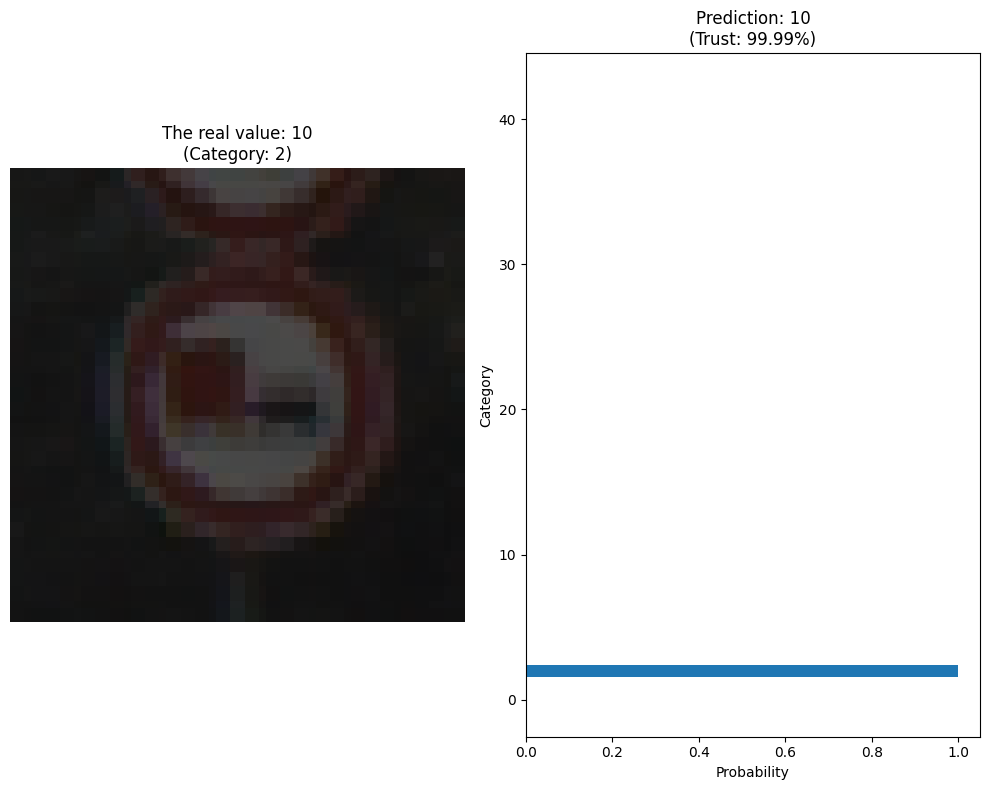

In [11]:
def predict_traffic_sign(model, image_path, class_dict):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=TARGET_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    class_name = class_dict.get(predicted_class, "Unknown")

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f'Prediction: {class_name} (Category: {predicted_class})\nTrust: {confidence:.2%}')
    plt.axis('off')
    plt.show()

    return predicted_class, class_name, confidence

print("Testing the model on images from the validation set:")
val_images, val_labels = next(val_generator)
sample_idx = 0

sample_image = val_images[sample_idx]
sample_label = np.argmax(val_labels[sample_idx])

test_image = np.expand_dims(sample_image, axis=0)

prediction = model.predict(test_image)
predicted_class = np.argmax(prediction[0])
true_class_name = classes_inv.get(sample_label, "Unknown")
predicted_class_name = classes_inv.get(predicted_class, "Unknown")
confidence = np.max(prediction[0])

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title(f'The real value: {true_class_name}\n(Category: {sample_label})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.barh(range(len(prediction[0])), prediction[0])
plt.title(f'Prediction: {predicted_class_name}\n(Trust: {confidence:.2%})')
plt.xlabel('Probability')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [12]:
model.save(MODEL_SAVE_PATH)
print(f"The model has been saved in: {MODEL_SAVE_PATH}")

training_history = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

with open('training_history.json', 'w') as f:
    json.dump(training_history, f)

print("The training date has been saved")

final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print("\n" + "="*50)
print("Summary of final results:")
print("="*50)
print(f"Final training accuracy: {final_train_accuracy:.2%}")
print(f"Final verification accuracy: {final_val_accuracy:.2%}")
print(f"Number of categories: {NUM_CLASSES}")
print(f"Number of training images: {train_generator.samples}")
print(f"Number of verification images: {val_generator.samples}")
print("="*50)

The model has been saved in: traffic_sign_model.h5
The training date has been saved

Summary of final results:
Final training accuracy: 97.28%
Final verification accuracy: 93.84%
Number of categories: 43
Number of training images: 33337
Number of verification images: 5872


In [13]:
class TrafficSignPredictor:
    def __init__(self, model_path, classes_json_path):
        self.model = tf.keras.models.load_model(model_path)
        with open(classes_json_path, 'r') as f:
            self.classes = json.load(f)

    def predict_image(self, image_path):
        return predict_traffic_sign(self.model, image_path, self.classes)

    def predict_array(self, image_array):
        if len(image_array.shape) == 3:
            image_array = np.expand_dims(image_array, axis=0)

        image_array = image_array / 255.0
        predictions = self.model.predict(image_array)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        class_name = self.classes.get(predicted_class, "unknown")

        return predicted_class, class_name, confidence

print("Initializing traffic signal predictor...")
predictor = TrafficSignPredictor(MODEL_SAVE_PATH, CLASSES_JSON)
print("Ready to use!")

import pickle
with open('traffic_sign_predictor.pkl', 'wb') as f:
    pickle.dump(predictor, f)

print("The predictor has been saved in a pickle file")

Initializing traffic signal predictor...


Ready to use!
The predictor has been saved in a pickle file


In [14]:
!pip install streamlit -q
!pip install pyngrok -q
!npm install localtunnel -g

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 125.1 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [15]:
import streamlit as st
import base64
from io import BytesIO
import tempfile
import requests

def create_streamlit_app():
    if 'predictor' not in st.session_state:
        try:
            st.session_state.predictor = TrafficSignPredictor(MODEL_SAVE_PATH, CLASSES_JSON)
        except:
            st.error("⚠️ لم يتم تحميل النموذج بنجاح. تأكد من تدريب النموذج أولاً.")
            return

    st.set_page_config(
        page_title="نظام التعرف على إشارات المرور الألمانية",
        page_icon="🚦",
        layout="wide"
    )

    st.markdown("""
    <style>
    .main-header {
        font-size: 2.5rem;
        color: #1f77b4;
        text-align: center;
        margin-bottom: 2rem;
    }
    .prediction-card {
        background-color: #f0f2f6;
        padding: 2rem;
        border-radius: 10px;
        margin: 1rem 0;
    }
    .confidence-high {
        color: #28a745;
        font-weight: bold;
    }
    .confidence-medium {
        color: #ffc107;
        font-weight: bold;
    }
    .confidence-low {
        color: #dc3545;
        font-weight: bold;
    }
    </style>
    """, unsafe_allow_html=True)

    st.markdown('<h1 class="main-header">🚦 نظام التعرف على إشارات المرور الألمانية</h1>', unsafe_allow_html=True)

    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("📤 رفع صورة إشارة مرور")

        upload_option = st.radio(
            "اختر طريقة الرفع:",
            ["رفع صورة من الجهاز", "استخدام رابط الصورة", "اختيار من أمثلة التدريب"]
        )

        image = None
        image_source = ""

        if upload_option == "رفع صورة من الجهاز":
            uploaded_file = st.file_uploader(
                "اختر صورة إشارة مرور",
                type=['png', 'jpg', 'jpeg'],
                help="Supported formats: PNG, JPG, JPEG"
            )
            if uploaded_file is not None:
                image = uploaded_file.read()
                image_source = "uploaded"

        elif upload_option == "استخدام رابط الصورة":
            image_url = st.text_input("أدخل رابط الصورة:")
            if image_url:
                try:
                    response = requests.get(image_url)
                    if response.status_code == 200:
                        image = response.content
                        image_source = "url"
                    else:
                        st.error("❌ تعذر تحميل الصورة من الرابط المحدد")
                except:
                    st.error("❌ رابط غير صالح")

        else:
            st.info("📸 اختر صورة من مجموعة التحقق للاختبار")
            if st.button("🎲 توليد صورة عشوائية للاختبار"):
                val_generator.reset()
                test_images, test_labels = next(val_generator)
                random_idx = np.random.randint(0, len(test_images))

                test_image = (test_images[random_idx] * 255).astype(np.uint8)
                buf = BytesIO()
                plt.imsave(buf, test_image, format='png')
                image = buf.getvalue()
                image_source = f"test_{random_idx}"
                st.session_state.test_label = np.argmax(test_labels[random_idx])

    with col2:
        st.subheader("🔍 نتيجة التحليل")

        if image is not None:
            st.image(image, use_column_width=True, caption="الصورة المرفوعة")

            try:
                with tempfile.NamedTemporaryFile(delete=False, suffix='.png') as tmp_file:
                    tmp_file.write(image)
                    tmp_file_path = tmp_file.name

                predicted_class, class_name, confidence = st.session_state.predictor.predict_image(tmp_file_path)

                st.markdown('<div class="prediction-card">', unsafe_allow_html=True)
                st.subheader("📊 نتائج التنبؤ")

                if confidence > 0.8:
                    confidence_class = "confidence-high"
                elif confidence > 0.5:
                    confidence_class = "confidence-medium"
                else:
                    confidence_class = "confidence-low"

                st.markdown(f"""
                **الفئة المتوقعة:** `{class_name}`

                **رقم الفئة:** `{predicted_class}`

                **مستوى الثقة:** <span class="{confidence_class}">{confidence:.2%}</span>
                """, unsafe_allow_html=True)

                if image_source.startswith("test_"):
                    true_class = st.session_state.test_label
                    true_class_name = classes_inv.get(true_class, "غير معروف")
                    is_correct = predicted_class == true_class

                    st.markdown("---")
                    st.subheader("🧪 نتائج الاختبار")
                    if is_correct:
                        st.success(f"✅ التنبؤ صحيح! الفئة الحقيقية: {true_class_name}")
                    else:
                        st.error(f"❌ التنبؤ خاطئ! الفئة الحقيقية: {true_class_name}")

                st.markdown('</div>', unsafe_allow_html=True)

                import os
                os.unlink(tmp_file_path)

            except Exception as e:
                st.error(f"❌ حدث خطأ في معالجة الصورة: {str(e)}")

        else:
            st.info("👆 قم برفع صورة إشارة مرور لرؤية نتائج التنبؤ")

    st.markdown("---")
    col3, col4, col5 = st.columns(3)

    with col3:
        st.subheader("📈 إحصائيات النموذج")
        if 'history' in globals():
            final_accuracy = history.history['val_accuracy'][-1]
            st.metric("دقة التحقق النهائية", f"{final_accuracy:.2%}")
        else:
            st.metric("عدد الفئات", NUM_CLASSES)

    with col4:
        st.subheader("ℹ️ معلومات المشروع")
        st.write("""
        - **المجموعة البيانات:** إشارات المرور الألمانية (GTSRB)
        - **عدد الفئات:** 43 فئة مختلفة
        - **التقنية:** شبكة عصبية تلافيفية (CNN)
        - **الاستخدام:** التعرف التلقائي على إشارات المرور
        """)

    with col5:
        st.subheader("🎯 كيفية الاستخدام")
        st.write("""
        1. ارفع صورة إشارة مرور
        2. انتظر تحليل النموذج
        3. اطلع على النتائج والتوقعات
        4. اختبر دقة النموذج
        """)

    st.markdown("---")
    st.subheader("💾 تحميل النموذج والبيانات")

    col6, col7 = st.columns(2)

    with col6:
        if st.button("🔄 إعادة تحميل النموذج"):
            try:
                st.session_state.predictor = TrafficSignPredictor(MODEL_SAVE_PATH, CLASSES_JSON)
                st.success("✅ تم تحميل النموذج بنجاح!")
            except Exception as e:
                st.error(f"❌ فشل في تحميل النموذج: {str(e)}")

    with col7:
        if st.button("📊 عرض إحصائيات التدريب"):
            if 'history' in globals():
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))

                axes[0].plot(history.history['accuracy'], label='تدريب')
                axes[0].plot(history.history['val_accuracy'], label='تحقق')
                axes[0].set_title('دقة النموذج')
                axes[0].legend()

                axes[1].plot(history.history['loss'], label='تدريب')
                axes[1].plot(history.history['val_loss'], label='تحقق')
                axes[1].set_title('خسارة النموذج')
                axes[1].legend()

                st.pyplot(fig)
            else:
                st.warning("⚠️ لا توجد بيانات تدريب متاحة")

def run_streamlit_in_notebook():

    streamlit_code = '''
import streamlit as st
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import json
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import tempfile
import sys
import os

sys.path.append(os.getcwd())

class TrafficSignPredictor:
    def __init__(self, model_path, classes_json_path):
        self.model = tf.keras.models.load_model(model_path)
        with open(classes_json_path, 'r') as f:
            self.classes = json.load(f)

    def predict_image(self, image_path):
        """التنبؤ بإشارة المرور من مسار الصورة"""
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=(64, 64))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        predictions = self.model.predict(img_array)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        class_name = self.classes.get(predicted_class, "غير معروف")

        return predicted_class, class_name, confidence

st.set_page_config(page_title="نظام التعرف على إشارات المرور", layout="wide")

st.title("🚦 نظام التعرف على إشارات المرور الألمانية")

@st.cache_resource
def load_predictor():
    try:
        return TrafficSignPredictor('traffic_sign_model.h5', 'classes.json')
    except:
        st.error("لم يتم العثور على النموذج المدرب")
        return None

predictor = load_predictor()

if predictor:
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("رفع صورة إشارة مرور")
        uploaded_file = st.file_uploader("اختر صورة", type=['png', 'jpg', 'jpeg'])

        if uploaded_file is not None:
            with tempfile.NamedTemporaryFile(delete=False, suffix='.png') as tmp_file:
                tmp_file.write(uploaded_file.getvalue())
                tmp_path = tmp_file.name

            predicted_class, class_name, confidence = predictor.predict_image(tmp_path)

            st.image(uploaded_file, caption="الصورة المرفوعة", use_column_width=True)

            st.subheader("نتائج التنبؤ")
            st.write(f"**الفئة:** {class_name}")
            st.write(f"**رقم الفئة:** {predicted_class}")
            st.write(f"**مستوى الثقة:** {confidence:.2%}")

            os.unlink(tmp_path)

    with col2:
        st.subheader("معلومات المشروع")
        st.write("""
        هذا النظام يستخدم الذكاء الاصطناعي للتعرف على إشارات المرور الألمانية.

        **المميزات:**
        - التعرف على 43 نوعاً مختلفاً من إشارات المرور
        - دقة عالية في التصنيف
        - واجهة سهلة الاستخدام
        """)
'''

    with open('traffic_sign_app.py', 'w', encoding='utf-8') as f:
        f.write(streamlit_code)

    print("✅ تم إنشاء تطبيق Streamlit!")
    print("📁 اسم الملف: traffic_sign_app.py")
    print("\nلتشغيل التطبيق، استخدم الأمر التالي في terminal:")
    print("streamlit run traffic_sign_app.py")
    print("\nأو لتشغيله في هذه الخلية، استخدم:")

def show_simple_interface():
    from IPython.display import display, clear_output
    import ipywidgets as widgets

    print("🚦 واجهة التنبؤ بإشارات المرور (مبسطة)")
    print("=" * 50)

    upload_button = widgets.FileUpload(
        description="رفع صورة",
        accept='.png,.jpg,.jpeg',
        multiple=False
    )

    predict_button = widgets.Button(description="تنبؤ", button_style='success')
    clear_button = widgets.Button(description="مسح", button_style='warning')

    output = widgets.Output()

    def on_predict_click(b):
        with output:
            clear_output()
            if upload_button.value:
                uploaded_file = list(upload_button.value.values())[0]
                image_data = uploaded_file['content']

                with tempfile.NamedTemporaryFile(delete=False, suffix='.png') as tmp_file:
                    tmp_file.write(image_data)
                    tmp_path = tmp_file.name

                try:
                    predictor = TrafficSignPredictor(MODEL_SAVE_PATH, CLASSES_JSON)
                    predicted_class, class_name, confidence = predictor.predict_image(tmp_path)

                    img = Image.open(BytesIO(image_data))
                    plt.figure(figsize=(8, 6))
                    plt.imshow(img)
                    plt.title(f'التنبؤ: {class_name}\nالثقة: {confidence:.2%}')
                    plt.axis('off')
                    plt.show()

                    print(f"🎯 الفئة المتوقعة: {class_name}")
                    print(f"🔢 رقم الفئة: {predicted_class}")
                    print(f"📊 مستوى الثقة: {confidence:.2%}")

                    os.unlink(tmp_path)

                except Exception as e:
                    print(f"❌ خطأ: {e}")
            else:
                print("⚠️ يرجى رفع صورة أولاً")

    def on_clear_click(b):
        upload_button.value.clear()
        with output:
            clear_output()

    predict_button.on_click(on_predict_click)
    clear_button.on_click(on_clear_click)

    display(widgets.VBox([
        widgets.HBox([upload_button, predict_button, clear_button]),
        output
    ]))

print("اختر طريقة تشغيل الواجهة:")
print("1. إنشاء تطبيق Streamlit كامل (يحتاج terminal)")
print("2. واجهة مبسطة داخل النوت بوك")

# run_streamlit_in_notebook()
show_simple_interface()

اختر طريقة تشغيل الواجهة:
1. إنشاء تطبيق Streamlit كامل (يحتاج terminal)
2. واجهة مبسطة داخل النوت بوك
🚦 واجهة التنبؤ بإشارات المرور (مبسطة)
